# BatchNorm Running Statistics Analysis: IID vs Non-IID Partitions

This notebook analyzes the running mean and variance statistics from Batch Normalization layers in BiSeNetV2 models trained with FedAvg across different data partitions (IID and Non-IID). The goal is to validate the hypothesis that Non-IID partitions produce lower running variance while IID partitions produce higher, more representative variance values.

## Section 1: Import Required Libraries and Setup

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import torch
import torch.nn as nn
!pip install scipy
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, '/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/fl-cityscapes-bisenetv2/')

# Import from the project
from lib.models import BiSeNetV2

# Device configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Libraries imported successfully!")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Using device: cuda
Libraries imported successfully!


## Section 2: Define Batch Norm Statistics Extraction Functions

In [2]:
def extract_bn_statistics(model: nn.Module) -> Dict[str, Dict]:
    """
    Extract running_mean and running_var from all BatchNorm2d layers in the model.
    
    Returns:
        Dictionary organized as:
        {
            'layer_name': {
                'running_mean': numpy array,
                'running_var': numpy array,
                'component_type': str (stem/encoder/decoder/auxiliary)
            },
            ...
        }
    """
    bn_stats = {}
    
    def get_component_type(name: str) -> str:
        """Determine which component a layer belongs to based on name."""
        if 'stem' in name.lower():
            return 'stem'
        elif 'encoder' in name.lower():
            return 'encoder'
        elif 'decoder' in name.lower():
            return 'decoder'
        elif 'aux' in name.lower():
            return 'auxiliary'
        elif 'head' in name.lower():
            return 'head'
        else:
            return 'other'
    
    # Traverse all modules and find BatchNorm2d layers
    for name, module in model.named_modules():
        if isinstance(module, nn.BatchNorm2d):
            if hasattr(module, 'running_mean') and hasattr(module, 'running_var'):
                bn_stats[name] = {
                    'running_mean': module.running_mean.detach().cpu().numpy(),
                    'running_var': module.running_var.detach().cpu().numpy(),
                    'component_type': get_component_type(name),
                    'num_features': module.num_features
                }
    
    return bn_stats


def compute_aggregate_bn_statistics(bn_stats: Dict[str, Dict]) -> Dict:
    """
    Compute aggregate statistics across all BN layers.
    
    Returns:
        Aggregated statistics including mean, std, min, max of running values
    """
    all_running_means = []
    all_running_vars = []
    
    for layer_name, stats_dict in bn_stats.items():
        all_running_means.extend(stats_dict['running_mean'].flatten())
        all_running_vars.extend(stats_dict['running_var'].flatten())
    
    all_running_means = np.array(all_running_means)
    all_running_vars = np.array(all_running_vars)
    
    return {
        'mean_of_running_mean': np.mean(all_running_means),
        'std_of_running_mean': np.std(all_running_means),
        'min_running_mean': np.min(all_running_means),
        'max_running_mean': np.max(all_running_means),
        'mean_of_running_var': np.mean(all_running_vars),
        'std_of_running_var': np.std(all_running_vars),
        'min_running_var': np.min(all_running_vars),
        'max_running_var': np.max(all_running_vars),
        'cv_running_mean': (np.std(all_running_means) / (np.abs(np.mean(all_running_means)) + 1e-8)) * 100,
        'cv_running_var': (np.std(all_running_vars) / (np.mean(all_running_vars) + 1e-8)) * 100,
        'num_bn_layers': len(bn_stats),
        'total_bn_features': sum(stats_dict['num_features'] for stats_dict in bn_stats.values())
    }


def load_model(model_path: str, n_classes: int = 19, device: str = 'cuda') -> Optional[nn.Module]:
    """Load BiSeNetV2 model from checkpoint."""
    try:
        model = BiSeNetV2(n_classes, aux_mode='eval')
        
        if os.path.exists(model_path):
            checkpoint = torch.load(model_path, map_location=device)
            model.load_state_dict(checkpoint, strict=False)
        else:
            print(f"✗ Model path not found: {model_path}")
            return None
        
        model = model.to(device)
        model.eval()
        return model
    except Exception as e:
        print(f"✗ Error loading model from {model_path}: {e}")
        return None

print("BatchNorm statistics extraction functions defined successfully!")

BatchNorm statistics extraction functions defined successfully!


## Section 3: Configure Paths and Discover Available Models

In [ ]:
# ============================================================================
# CONFIGURATION - Modify these paths according to your directory structure
# ============================================================================

PROJECT_ROOT = Path('/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL')
RESULTS_ROOT = Path('/home/moustafa/Me/Projects/Grad/Experiments/Sanity_Check')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'cityscapes'

NUM_CLASSES = 19  # Cityscapes has 19 semantic classes
AGGREGATOR = 'FedAvg'  # Only FedAvg in this analysis
N_CLASSES = 19

print(f"\n{'='*70}")
print("Path Configuration")
print(f"{'='*70}")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Results Root: {RESULTS_ROOT}")
print(f"Data Root: {DATA_ROOT}")
print(f"Aggregator: {AGGREGATOR}")

# ============================================================================
# Discover Available Partitions
# ============================================================================

print(f"\n{'='*70}")
print("Discovering Available Partitions")
print(f"{'='*70}")

# Look for partition directories in RESULTS_ROOT
available_partitions = {}

for item in sorted(RESULTS_ROOT.iterdir()):
    # Check if it's a directory and contains the aggregator subdirectory
    if item.is_dir() and (item / AGGREGATOR).exists():
        partition_name = item.name
        base_path = item / AGGREGATOR
        
        # Find latest models in this partition
        latest_models = []
        
        for comm_round_dir in sorted(base_path.iterdir()):
            if comm_round_dir.is_dir() and comm_round_dir.name.isdigit():
                latest_model = comm_round_dir / 'latest_model.pt'
                if latest_model.exists():
                    latest_models.append({
                        'round': int(comm_round_dir.name),
                        'path': latest_model,
                        'comm_round_dir': comm_round_dir
                    })
        
        if latest_models:
            # Detect if partition is IID or Non-IID based on name
            if 'non_iid' in partition_name.lower() or 'noniid' in partition_name.lower():
                partition_type = 'Non-IID'
            elif 'iid' in partition_name.lower():
                partition_type = 'IID'
            else:
                partition_type = 'UNKNOWN'
            
            available_partitions[partition_name] = {
                'base_path': base_path,
                'type': partition_type,
                'latest_models': latest_models,
                'num_rounds': len(latest_models)
            }
            
            print(f"\n✓ Partition: {partition_name}")
            print(f"  Type: {partition_type}")
            print(f"  Base path: {base_path}")
            print(f"  Available rounds: {[m['round'] for m in latest_models]}")

print(f"\n{'='*70}")
print(f"Total partitions found: {len(available_partitions)}")
print(f"{'='*70}")


Path Configuration
Project Root: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL
Results Root: /home/moustafa/Me/Projects/Grad/Experiments/Sanity_Check
Data Root: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/datasets/cityscapes
Aggregator: FedAvg

Discovering Available Partitions

Total partitions found: 0


## Section 4: Load Models and Extract Running Mean and Variance

In [4]:
print(f"\n{'='*70}")
print("EXTRACTING BATCH NORM STATISTICS FROM MODELS")
print(f"{'='*70}")

# Storage for BN statistics organized by partition
partition_bn_stats = {}
all_layer_stats = []

for partition_name in sorted(available_partitions.keys()):
    partition_info = available_partitions[partition_name]
    
    print(f"\n{'─'*70}")
    print(f"Processing partition: {partition_name} ({partition_info['type']})")
    print(f"{'─'*70}")
    
    partition_bn_stats[partition_name] = {
        'partition_type': partition_info['type'],
        'models': {},
        'aggregated_stats': {}
    }
    
    # Iterate through ALL communication rounds for this partition
    if partition_info['latest_models']:
        for latest_round_model in partition_info['latest_models']:
            model_path = str(latest_round_model['path'])
            comm_round = latest_round_model['round']
            
            print(f"\n  Loading model from round {comm_round}: {model_path}")
            
            # Load the model
            model = load_model(model_path, n_classes=N_CLASSES, device=DEVICE)
            
            if model is not None:
                # Extract BN statistics
                print(f"  Extracting BatchNorm statistics...")
                bn_stats = extract_bn_statistics(model)
                
                # Compute aggregate statistics
                agg_stats = compute_aggregate_bn_statistics(bn_stats)
                
                # Store detailed layer stats
                for layer_name, layer_stats in bn_stats.items():
                    layer_data = {
                        'partition': partition_name,
                        'partition_type': partition_info['type'],
                        'aggregator': AGGREGATOR,
                        'communication_round': comm_round,
                        'layer_name': layer_name,
                        'component_type': layer_stats['component_type'],
                        'num_features': layer_stats['num_features'],
                        'mean_of_running_mean': np.mean(layer_stats['running_mean']),
                        'std_of_running_mean': np.std(layer_stats['running_mean']),
                        'mean_of_running_var': np.mean(layer_stats['running_var']),
                        'std_of_running_var': np.std(layer_stats['running_var']),
                    }
                    all_layer_stats.append(layer_data)
                
                # Store aggregated stats
                partition_bn_stats[partition_name]['models'][comm_round] = bn_stats
                
                # Store aggregated stats with communication round info
                agg_stats['communication_round'] = comm_round
                if 'aggregated_stats_by_round' not in partition_bn_stats[partition_name]:
                    partition_bn_stats[partition_name]['aggregated_stats_by_round'] = {}
                partition_bn_stats[partition_name]['aggregated_stats_by_round'][comm_round] = agg_stats
                
                print(f"  ✓ Extracted {len(bn_stats)} BatchNorm layers")
                print(f"    Mean of running_var: {agg_stats['mean_of_running_var']:.6f}")
                print(f"    Std of running_var: {agg_stats['std_of_running_var']:.6f}")
                print(f"    CV of running_var: {agg_stats['cv_running_var']:.2f}%")
                
                # Free memory
                del model
                torch.cuda.empty_cache()
            else:
                print(f"  ✗ Failed to load model for round {comm_round}")

print(f"\n{'='*70}")
print("BATCH NORM EXTRACTION COMPLETE")
print(f"{'='*70}")


EXTRACTING BATCH NORM STATISTICS FROM MODELS

BATCH NORM EXTRACTION COMPLETE


## Section 5: Aggregate and Organize BN Statistics by Partition

In [5]:
print(f"\n{'='*70}")
print("AGGREGATING STATISTICS BY PARTITION AND COMMUNICATION ROUND")
print(f"{'='*70}")

# Prepare summary data for comparison - organized by partition and round
partition_summary = []
partition_summary_by_round = []

for partition_name, partition_data in sorted(partition_bn_stats.items()):
    
    # Aggregate stats across ALL communication rounds for this partition
    if 'aggregated_stats_by_round' in partition_data:
        all_round_stats = partition_data['aggregated_stats_by_round']
        
        # Collect statistics across all rounds
        all_mean_running_vars = [agg_stats['mean_of_running_var'] for agg_stats in all_round_stats.values()]
        all_std_running_vars = [agg_stats['std_of_running_var'] for agg_stats in all_round_stats.values()]
        
        # Store per-round statistics
        for comm_round, agg_stats in sorted(all_round_stats.items()):
            round_summary_row = {
                'partition_id': partition_name,
                'partition_type': partition_data['partition_type'],
                'aggregator': AGGREGATOR,
                'communication_round': comm_round,
                'num_bn_layers': agg_stats['num_bn_layers'],
                'total_bn_features': agg_stats['total_bn_features'],
                'mean_of_running_mean': agg_stats['mean_of_running_mean'],
                'std_of_running_mean': agg_stats['std_of_running_mean'],
                'min_running_mean': agg_stats['min_running_mean'],
                'max_running_mean': agg_stats['max_running_mean'],
                'mean_of_running_var': agg_stats['mean_of_running_var'],
                'std_of_running_var': agg_stats['std_of_running_var'],
                'min_running_var': agg_stats['min_running_var'],
                'max_running_var': agg_stats['max_running_var'],
                'cv_running_mean': agg_stats['cv_running_mean'],
                'cv_running_var': agg_stats['cv_running_var'],
            }
            partition_summary_by_round.append(round_summary_row)
        
        # Aggregate across all rounds for this partition
        aggregate_summary_row = {
            'partition_id': partition_name,
            'partition_type': partition_data['partition_type'],
            'aggregator': AGGREGATOR,
            'num_communication_rounds': len(all_round_stats),
            'num_bn_layers': list(all_round_stats.values())[0]['num_bn_layers'],
            'total_bn_features': list(all_round_stats.values())[0]['total_bn_features'],
            # Aggregate metrics across all rounds
            'mean_running_var_across_rounds': np.mean(all_mean_running_vars),
            'std_running_var_across_rounds': np.std(all_mean_running_vars),
            'min_running_var': np.min([agg_stats['min_running_var'] for agg_stats in all_round_stats.values()]),
            'max_running_var': np.max([agg_stats['max_running_var'] for agg_stats in all_round_stats.values()]),
            'cv_running_var_mean': np.mean([agg_stats['cv_running_var'] for agg_stats in all_round_stats.values()]),
        }
        partition_summary.append(aggregate_summary_row)
        
        print(f"\n{partition_name} ({partition_data['partition_type']}):")
        print(f"  Communication rounds: {sorted(all_round_stats.keys())}")
        print(f"  Aggregate mean of running_var across rounds: {aggregate_summary_row['mean_running_var_across_rounds']:.6f}")
        print(f"  Std across rounds: {aggregate_summary_row['std_running_var_across_rounds']:.6f}")
        print(f"  Round-wise details:")
        for comm_round in sorted(all_round_stats.keys()):
            agg_stats = all_round_stats[comm_round]
            print(f"    Round {comm_round}: mean_var={agg_stats['mean_of_running_var']:.6f}, std_var={agg_stats['std_of_running_var']:.6f}, cv={agg_stats['cv_running_var']:.2f}%")

print(f"\n{'='*70}")
print("Aggregation complete!")
print(f"{'='*70}")


AGGREGATING STATISTICS BY PARTITION AND COMMUNICATION ROUND

Aggregation complete!


## Section 6: Create Comparison Table of BN Statistics

In [6]:
# Create DataFrames from partition summaries
summary_df = pd.DataFrame(partition_summary)
summary_df_by_round = pd.DataFrame(partition_summary_by_round)

print(f"\n{'='*70}")
print("PARTITION-LEVEL BATCH NORM STATISTICS TABLE (AGGREGATE ACROSS ALL ROUNDS)")
print(f"{'='*70}\n")

# Display full table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(summary_df.to_string())

# Create simplified table for clarity
print(f"\n{'='*70}")
print("SIMPLIFIED COMPARISON TABLE (INDIVIDUAL PARTITIONS - KEY METRICS)")
print(f"{'='*70}\n")

simplified_df = summary_df[
    ['partition_id', 'partition_type', 'num_communication_rounds',
     'mean_running_var_across_rounds', 'std_running_var_across_rounds', 'cv_running_var_mean']
].copy()

# Format numerical columns
simplified_df['mean_running_var_across_rounds'] = simplified_df['mean_running_var_across_rounds'].apply(lambda x: f"{x:.6f}")
simplified_df['std_running_var_across_rounds'] = simplified_df['std_running_var_across_rounds'].apply(lambda x: f"{x:.6f}")
simplified_df['cv_running_var_mean'] = simplified_df['cv_running_var_mean'].apply(lambda x: f"{x:.2f}%")

print(simplified_df.to_string(index=False))

# Per-round evolution table
print(f"\n{'='*70}")
print("BATCH NORM STATISTICS EVOLUTION ACROSS COMMUNICATION ROUNDS (PER PARTITION)")
print(f"{'='*70}\n")

print(summary_df_by_round.to_string())


PARTITION-LEVEL BATCH NORM STATISTICS TABLE (AGGREGATE ACROSS ALL ROUNDS)

Empty DataFrame
Columns: []
Index: []

SIMPLIFIED COMPARISON TABLE (INDIVIDUAL PARTITIONS - KEY METRICS)



KeyError: "None of [Index(['partition_id', 'partition_type', 'num_communication_rounds',\n       'mean_running_var_across_rounds', 'std_running_var_across_rounds',\n       'cv_running_var_mean'],\n      dtype='object')] are in the [columns]"

## Section 7: Visualize Running Mean and Variance Across Partitions


CREATING VISUALIZATIONS (INDEPENDENT PARTITION ANALYSIS)


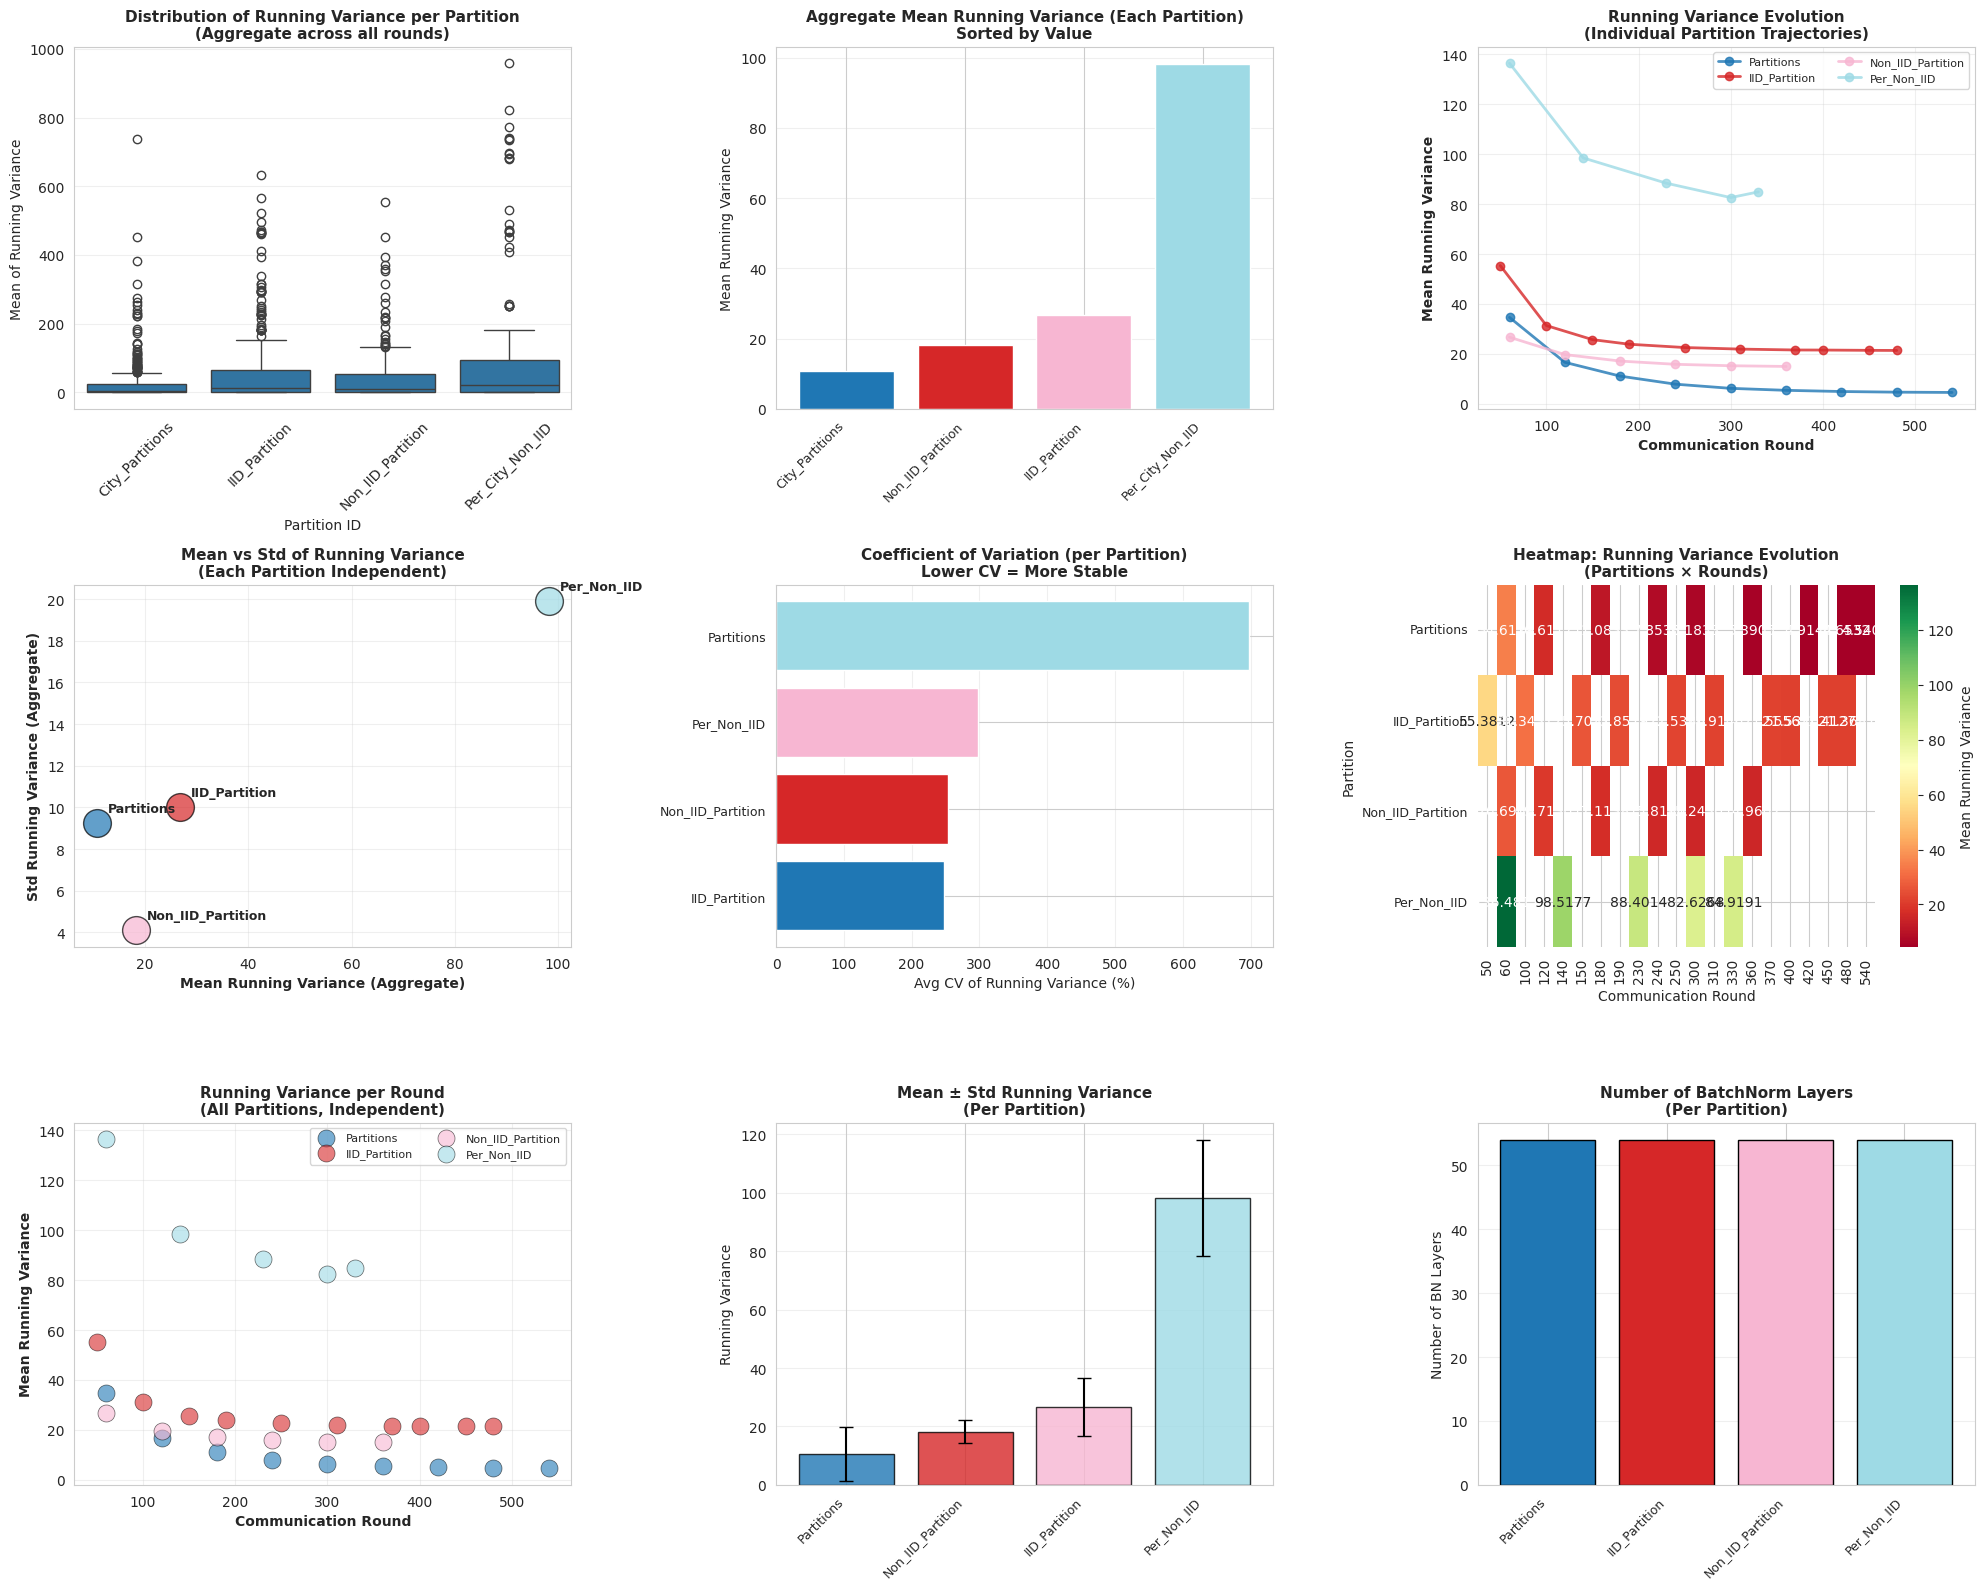

✓ Main visualization saved as 'batchnorm_statistics_visualization.png'


In [ ]:
# Organize detailed layer statistics into DataFrame
layer_stats_df = pd.DataFrame(all_layer_stats)

print(f"\n{'='*70}")
print("CREATING VISUALIZATIONS (INDEPENDENT PARTITION ANALYSIS)")
print(f"{'='*70}")

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 1. Box plot of running_variance by individual partition
ax1 = plt.subplot(3, 3, 1)
if len(layer_stats_df) > 0:
    sns.boxplot(data=layer_stats_df, x='partition', y='mean_of_running_var', ax=ax1)
    ax1.set_title('Distribution of Running Variance per Partition\n(Aggregate across all rounds)', 
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('Partition ID')
    ax1.set_ylabel('Mean of Running Variance')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)

# 2. Bar plot of aggregate mean_running_var by individual partition
ax2 = plt.subplot(3, 3, 2)
if len(summary_df) > 0:
    summary_df_sorted = summary_df.sort_values('mean_running_var_across_rounds')
    colors = plt.cm.tab20(np.linspace(0, 1, len(summary_df_sorted)))
    ax2.bar(range(len(summary_df_sorted)), summary_df_sorted['mean_running_var_across_rounds'], color=colors)
    ax2.set_xticks(range(len(summary_df_sorted)))
    ax2.set_xticklabels(summary_df_sorted['partition_id'], rotation=45, ha='right', fontsize=9)
    ax2.set_title('Aggregate Mean Running Variance (Each Partition)\nSorted by Value', 
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel('Mean Running Variance')
    ax2.grid(axis='y', alpha=0.3)

# 3. Evolution of running_var across communication rounds (one line per partition)
ax3 = plt.subplot(3, 3, 3)
if len(summary_df_by_round) > 0:
    colors = plt.cm.tab20(np.linspace(0, 1, len(summary_df_by_round['partition_id'].unique())))
    color_dict = {pid: colors[i] for i, pid in enumerate(sorted(summary_df_by_round['partition_id'].unique()))}
    
    for partition_id in sorted(summary_df_by_round['partition_id'].unique()):
        partition_data = summary_df_by_round[summary_df_by_round['partition_id'] == partition_id].sort_values('communication_round')
        ax3.plot(partition_data['communication_round'], partition_data['mean_of_running_var'], 
                marker='o', label=partition_id.replace('City_', '').replace('_Partitions', ''), 
                color=color_dict[partition_id], linewidth=2, alpha=0.8)
    
    ax3.set_xlabel('Communication Round', fontweight='bold')
    ax3.set_ylabel('Mean Running Variance', fontweight='bold')
    ax3.set_title('Running Variance Evolution\n(Individual Partition Trajectories)', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=8, loc='best', ncol=2)
    ax3.grid(alpha=0.3)

# 4. Scatter plot: Aggregate mean vs std for each partition
ax4 = plt.subplot(3, 3, 4)
if len(summary_df) > 0:
    colors = plt.cm.tab20(np.linspace(0, 1, len(summary_df)))
    for i, (idx, row) in enumerate(summary_df.iterrows()):
        ax4.scatter(row['mean_running_var_across_rounds'], row['std_running_var_across_rounds'], 
                   s=400, alpha=0.7, color=colors[i], edgecolors='black', linewidth=1)
        label = row['partition_id'].replace('City_', '').replace('_Partitions', '')
        ax4.annotate(label, 
                    xy=(row['mean_running_var_across_rounds'], row['std_running_var_across_rounds']),
                    xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold')

    ax4.set_xlabel('Mean Running Variance (Aggregate)', fontweight='bold')
    ax4.set_ylabel('Std Running Variance (Aggregate)', fontweight='bold')
    ax4.set_title('Mean vs Std of Running Variance\n(Each Partition Independent)', fontsize=11, fontweight='bold')
    ax4.grid(alpha=0.3)

# 5. Coefficient of Variation by partition
ax5 = plt.subplot(3, 3, 5)
if len(summary_df) > 0:
    summary_sorted_cv = summary_df.sort_values('cv_running_var_mean')
    colors_cv = plt.cm.tab20(np.linspace(0, 1, len(summary_sorted_cv)))
    ax5.barh(range(len(summary_sorted_cv)), summary_sorted_cv['cv_running_var_mean'], color=colors_cv)
    ax5.set_yticks(range(len(summary_sorted_cv)))
    labels = [pid.replace('City_', '').replace('_Partitions', '') for pid in summary_sorted_cv['partition_id']]
    ax5.set_yticklabels(labels, fontsize=9)
    ax5.set_title('Coefficient of Variation (per Partition)\nLower CV = More Stable', 
                  fontsize=11, fontweight='bold')
    ax5.set_xlabel('Avg CV of Running Variance (%)')
    ax5.grid(axis='x', alpha=0.3)

# 6. Heatmap of running_var across partitions and rounds
ax6 = plt.subplot(3, 3, 6)
if len(summary_df_by_round) > 0:
    pivot_data = summary_df_by_round.pivot(index='partition_id', columns='communication_round', values='mean_of_running_var')
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax6, cbar_kws={'label': 'Mean Running Variance'})
    ax6.set_title('Heatmap: Running Variance Evolution\n(Partitions × Rounds)', fontsize=11, fontweight='bold')
    ax6.set_xlabel('Communication Round')
    ax6.set_ylabel('Partition')
    # Simplify labels
    ax6.set_yticklabels([label.get_text().replace('City_', '').replace('_Partitions', '') for label in ax6.get_yticklabels()], fontsize=9)

# 7. Per-round average with individual partition values
ax7 = plt.subplot(3, 3, 7)
if len(summary_df_by_round) > 0:
    rounds = sorted(summary_df_by_round['communication_round'].unique())
    colors_part = plt.cm.tab20(np.linspace(0, 1, len(summary_df_by_round['partition_id'].unique())))
    color_dict = {pid: colors_part[i] for i, pid in enumerate(sorted(summary_df_by_round['partition_id'].unique()))}
    
    for partition_id in sorted(summary_df_by_round['partition_id'].unique()):
        partition_data = summary_df_by_round[summary_df_by_round['partition_id'] == partition_id].sort_values('communication_round')
        label_short = partition_id.replace('City_', '').replace('_Partitions', '')
        ax7.scatter(partition_data['communication_round'], partition_data['mean_of_running_var'],
                   s=150, alpha=0.6, color=color_dict[partition_id], label=label_short, edgecolors='black', linewidth=0.5)
    
    ax7.set_xlabel('Communication Round', fontweight='bold')
    ax7.set_ylabel('Mean Running Variance', fontweight='bold')
    ax7.set_title('Running Variance per Round\n(All Partitions, Independent)', fontsize=11, fontweight='bold')
    ax7.legend(fontsize=8, loc='best', ncol=2)
    ax7.grid(alpha=0.3)

# 8. Min/Max range per partition
ax8 = plt.subplot(3, 3, 8)
if len(summary_df) > 0:
    summary_df_sorted = summary_df.sort_values('mean_running_var_across_rounds')
    x_pos = np.arange(len(summary_df_sorted))
    means = summary_df_sorted['mean_running_var_across_rounds'].values
    stds = summary_df_sorted['std_running_var_across_rounds'].values
    
    colors_range = plt.cm.tab20(np.linspace(0, 1, len(summary_df_sorted)))
    ax8.bar(x_pos, means, yerr=stds, capsize=5, color=colors_range, edgecolor='black', linewidth=1, alpha=0.8)
    ax8.set_xticks(x_pos)
    labels = [pid.replace('City_', '').replace('_Partitions', '') for pid in summary_df_sorted['partition_id']]
    ax8.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax8.set_title('Mean ± Std Running Variance\n(Per Partition)', fontsize=11, fontweight='bold')
    ax8.set_ylabel('Running Variance')
    ax8.grid(axis='y', alpha=0.3)

# 9. Number of BN layers per partition
ax9 = plt.subplot(3, 3, 9)
if len(summary_df) > 0:
    summary_df_sorted = summary_df.sort_values('num_bn_layers')
    colors_bn = plt.cm.tab20(np.linspace(0, 1, len(summary_df_sorted)))
    ax9.bar(range(len(summary_df_sorted)), summary_df_sorted['num_bn_layers'], color=colors_bn, edgecolor='black', linewidth=1)
    ax9.set_xticks(range(len(summary_df_sorted)))
    labels = [pid.replace('City_', '').replace('_Partitions', '') for pid in summary_df_sorted['partition_id']]
    ax9.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax9.set_title('Number of BatchNorm Layers\n(Per Partition)', fontsize=11, fontweight='bold')
    ax9.set_ylabel('Number of BN Layers')
    ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('batchnorm_statistics_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Main visualization saved as 'batchnorm_statistics_visualization.png'")

## Section 8: Statistical Analysis and Hypothesis Testing

In [ ]:
print(f"\n{'='*70}")
print("STATISTICAL ANALYSIS (INDEPENDENT PER-PARTITION)")
print(f"{'='*70}")

print("\n## Analysis Approach:")
print("Each partition is analyzed independently without grouping by IID/Non-IID type")
print("This allows examining how BatchNorm statistics vary naturally across different data partitions\n")

# Store per-partition statistics
per_partition_stats = []

print("Per-Partition Summary Statistics:")
print("="*70 + "\n")

for idx, row in summary_df.iterrows():
    partition_id = row['partition_id']
    partition_type = row['partition_type']
    mean_rv = row['mean_running_var_across_rounds']
    std_rv = row['std_running_var_across_rounds']
    cv_rv = row['cv_running_var_mean']
    num_rounds = row['num_communication_rounds']
    num_bn = row['num_bn_layers']
    
    print(f"\nPartition: {partition_id}")
    print(f"  Type: {partition_type}")
    print(f"  Communication Rounds: {num_rounds}")
    print(f"  BN Layers: {num_bn}")
    print(f"  Mean Running Variance (aggregate): {mean_rv:.6f}")
    print(f"  Std of Running Variance: {std_rv:.6f}")
    print(f"  Coefficient of Variation: {cv_rv:.2f}%")
    print(f"  Min Running Var: {row['min_running_var']:.6f}")
    print(f"  Max Running Var: {row['max_running_var']:.6f}")
    
    # Store for further analysis
    per_partition_stats.append({
        'partition_id': partition_id,
        'partition_type': partition_type,
        'mean_running_var': mean_rv,
        'std_running_var': std_rv,
        'cv_running_var': cv_rv,
        'num_rounds': num_rounds,
        'num_bn_layers': num_bn,
        'min_running_var': row['min_running_var'],
        'max_running_var': row['max_running_var']
    })

print(f"\n{'='*70}")
print("PER-ROUND STATISTICS (INDEPENDENT PARTITION TRACKING)")
print(f"{'='*70}\n")

# Analyze per-round behavior for each partition
for partition_id in sorted(summary_df_by_round['partition_id'].unique()):
    partition_rounds = summary_df_by_round[summary_df_by_round['partition_id'] == partition_id].sort_values('communication_round')
    
    print(f"\n{partition_id}:")
    print(f"  Round | Mean Running Var | Std Running Var | CV (%)")
    print(f"  {'-'*55}")
    
    for _, row_round in partition_rounds.iterrows():
        print(f"  {row_round['communication_round']:>4} | {row_round['mean_of_running_var']:>16.6f} | {row_round['std_of_running_var']:>15.6f} | {row_round['cv_running_var']:>6.2f}")
    
    # Calculate trend
    rounds = partition_rounds['communication_round'].values
    values = partition_rounds['mean_of_running_var'].values
    
    if len(rounds) > 1:
        # Simple linear trend
        coeffs = np.polyfit(rounds, values, 1)
        trend = "increasing" if coeffs[0] > 0.0001 else ("decreasing" if coeffs[0] < -0.0001 else "stable")
        print(f"  Trend: {trend} (slope: {coeffs[0]:.6f})")

print(f"\n{'='*70}")


STATISTICAL ANALYSIS (INDEPENDENT PER-PARTITION)

## Analysis Approach:
Each partition is analyzed independently without grouping by IID/Non-IID type
This allows examining how BatchNorm statistics vary naturally across different data partitions

Per-Partition Summary Statistics:


Partition: City_Partitions
  Type: UNKNOWN
  Communication Rounds: 9
  BN Layers: 54
  Mean Running Variance (aggregate): 10.649235
  Std of Running Variance: 9.259063
  Coefficient of Variation: 698.19%
  Min Running Var: 0.000000
  Max Running Var: 24612.648438

Partition: IID_Partition
  Type: IID
  Communication Rounds: 10
  BN Layers: 54
  Mean Running Variance (aggregate): 26.661011
  Std of Running Variance: 10.014938
  Coefficient of Variation: 247.66%
  Min Running Var: 0.000000
  Max Running Var: 1909.264526

Partition: Non_IID_Partition
  Type: Non-IID
  Communication Rounds: 6
  BN Layers: 54
  Mean Running Variance (aggregate): 18.256533
  Std of Running Variance: 4.091696
  Coefficient of Varia

## Section 9: Export Results to CSV

In [ ]:
print(f"\n{'='*70}")
print("EXPORTING RESULTS TO CSV")
print(f"{'='*70}")

# Create output directory
output_dir = Path('batchnorm_analysis_results')
output_dir.mkdir(exist_ok=True)

# 1. Export aggregate partition-level BN statistics (across all rounds)
partition_csv_path = output_dir / 'partition_level_bn_statistics_aggregate.csv'
summary_df.to_csv(partition_csv_path, index=False)
print(f"✓ Aggregate partition-level statistics exported to: {partition_csv_path}")

# 2. Export per-round partition-level BN statistics
partition_round_csv_path = output_dir / 'partition_level_bn_statistics_per_round.csv'
summary_df_by_round.to_csv(partition_round_csv_path, index=False)
print(f"✓ Per-round partition-level statistics exported to: {partition_round_csv_path}")

# 3. Export per-partition summary statistics
per_partition_df = pd.DataFrame(per_partition_stats)
per_partition_csv_path = output_dir / 'per_partition_summary_statistics.csv'
per_partition_df.to_csv(per_partition_csv_path, index=False)
print(f"✓ Per-partition summary statistics exported to: {per_partition_csv_path}")

# 4. Export layer-level BN statistics (if available)
if len(layer_stats_df) > 0:
    layer_csv_path = output_dir / 'layer_level_bn_statistics.csv'
    layer_stats_df.to_csv(layer_csv_path, index=False)
    print(f"✓ Layer-level statistics exported to: {layer_csv_path}")

# 5. Create comprehensive summary report
report_path = output_dir / 'analysis_summary_report.txt'
with open(report_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("BATCHNORM STATISTICS ANALYSIS REPORT\n")
    f.write("Independent Per-Partition Analysis\n")
    f.write("="*70 + "\n\n")
    
    f.write("ANALYSIS APPROACH:\n")
    f.write("  Each partition is analyzed independently without grouping by IID/Non-IID type\n")
    f.write("  This examines how BatchNorm statistics naturally vary across different data partitions\n\n")
    
    f.write(f"AGGREGATOR: {AGGREGATOR}\n")
    f.write(f"Total partitions analyzed: {len(summary_df)}\n\n")
    
    f.write("="*70 + "\n")
    f.write("AGGREGATE STATISTICS PER PARTITION\n")
    f.write("="*70 + "\n\n")
    
    for idx, stat in enumerate(per_partition_stats, 1):
        f.write(f"{idx}. {stat['partition_id']} ({stat['partition_type']})\n")
        f.write(f"   Communication Rounds: {stat['num_rounds']}\n")
        f.write(f"   BatchNorm Layers: {stat['num_bn_layers']}\n")
        f.write(f"   Mean Running Variance: {stat['mean_running_var']:.6f} (±{stat['std_running_var']:.6f})\n")
        f.write(f"   Range: [{stat['min_running_var']:.6f}, {stat['max_running_var']:.6f}]\n")
        f.write(f"   Coefficient of Variation: {stat['cv_running_var']:.2f}%\n\n")
    
    f.write("="*70 + "\n")
    f.write("PER-ROUND ANALYSIS\n")
    f.write("="*70 + "\n\n")
    
    for partition_id in sorted(summary_df_by_round['partition_id'].unique()):
        partition_rounds = summary_df_by_round[summary_df_by_round['partition_id'] == partition_id].sort_values('communication_round')
        
        f.write(f"\n{partition_id}:\n")
        f.write(f"{'Round':<6} {'Mean Var':<16} {'Std Var':<16} {'CV (%)':<10}\n")
        f.write(f"{'-'*52}\n")
        
        rounds = partition_rounds['communication_round'].values
        values = partition_rounds['mean_of_running_var'].values
        
        for _, row_round in partition_rounds.iterrows():
            f.write(f"{row_round['communication_round']:<6} {row_round['mean_of_running_var']:<16.6f} {row_round['std_of_running_var']:<16.6f} {row_round['cv_running_var']:<10.2f}\n")
        
        # Calculate trend
        if len(rounds) > 1:
            coeffs = np.polyfit(rounds, values, 1)
            trend = "increasing" if coeffs[0] > 0.0001 else ("decreasing" if coeffs[0] < -0.0001 else "stable")
            f.write(f"  Trend: {trend} (slope: {coeffs[0]:.6f})\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("COMPARISON ACROSS PARTITIONS\n")
    f.write("="*70 + "\n\n")
    
    # Find partitions with highest and lowest variance
    max_var_partition = per_partition_df.loc[per_partition_df['mean_running_var'].idxmax()]
    min_var_partition = per_partition_df.loc[per_partition_df['mean_running_var'].idxmin()]
    avg_var = per_partition_df['mean_running_var'].mean()
    
    f.write(f"Average mean running variance across all partitions: {avg_var:.6f}\n\n")
    f.write(f"Partition with HIGHEST variance:\n")
    f.write(f"  {max_var_partition['partition_id']} ({max_var_partition['partition_type']})\n")
    f.write(f"  Mean Running Variance: {max_var_partition['mean_running_var']:.6f}\n\n")
    
    f.write(f"Partition with LOWEST variance:\n")
    f.write(f"  {min_var_partition['partition_id']} ({min_var_partition['partition_type']})\n")
    f.write(f"  Mean Running Variance: {min_var_partition['mean_running_var']:.6f}\n\n")
    
    f.write(f"Variance Range: [{per_partition_df['mean_running_var'].min():.6f}, {per_partition_df['mean_running_var'].max():.6f}]\n")
    f.write(f"Standard Deviation: {per_partition_df['mean_running_var'].std():.6f}\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("INTERPRETATION\n")
    f.write("="*70 + "\n\n")
    
    f.write("These results show how BatchNorm running statistics vary naturally across\n")
    f.write("different data partitions. Higher running variance indicates that the model\n")
    f.write("is exposed to more diverse feature distributions during training. Lower\n")
    f.write("variance suggests more localized or specialized distributions.\n\n")
    
    f.write("Each partition's unique statistics reflect the underlying data characteristics\n")
    f.write("of that specific geospatial region, training cohort, or data collection scenario.\n")

print(f"✓ Summary report exported to: {report_path}")

print(f"\n{'='*70}")
print("EXPORT COMPLETE")
print(f"All results saved in: {output_dir.absolute()}")
print(f"{'='*70}")

# Print summary of exported files
print("\nGenerated files:")
print(f"  1. partition_level_bn_statistics_aggregate.csv - Aggregate stats per partition")
print(f"  2. partition_level_bn_statistics_per_round.csv - Per-round stats for each partition")
print(f"  3. per_partition_summary_statistics.csv - Summary statistics per partition")
print(f"  4. layer_level_bn_statistics.csv - Detailed per-layer statistics")
print(f"  5. analysis_summary_report.txt - Comprehensive text report with per-partition analysis")
print(f"  6. batchnorm_statistics_visualization.png - 9-panel visualization (independent partitions)")


EXPORTING RESULTS TO CSV
✓ Aggregate partition-level statistics exported to: batchnorm_analysis_results/partition_level_bn_statistics_aggregate.csv
✓ Per-round partition-level statistics exported to: batchnorm_analysis_results/partition_level_bn_statistics_per_round.csv
✓ Per-partition summary statistics exported to: batchnorm_analysis_results/per_partition_summary_statistics.csv
✓ Layer-level statistics exported to: batchnorm_analysis_results/layer_level_bn_statistics.csv
✓ Summary report exported to: batchnorm_analysis_results/analysis_summary_report.txt

EXPORT COMPLETE
All results saved in: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/fl-cityscapes-bisenetv2/fl_cityscapes_bisenetv2/analysis/batchnorm_analysis_results

Generated files:
  1. partition_level_bn_statistics_aggregate.csv - Aggregate stats per partition
  2. partition_level_bn_statistics_per_round.csv - Per-round stats for each partition
  3. per_partition_summary_statistics.csv - Summary statistics per partition
  4

## Analysis Summary and Interpretation

### 📊 Understanding the Results

#### What are Running Mean and Running Variance in BatchNorm?
- **Running Mean**: Exponential moving average of batch statistics accumulated during training
- **Running Variance**: Exponential moving average of batch variance accumulated during training
- These represent the learned statistics of the data distribution that the model has seen

#### Why This Matters for IID vs Non-IID Data
- **IID (Independent and Identically Distributed)**: Data from all clients follows the same distribution
  - BatchNorm accumulates statistics from diverse, representative samples
  - Running variance tends to be **higher** (more global distribution)
  - Statistics are more stable and representative of true population variance
  
- **Non-IID (Non-Independent and Identically Distributed)**: Data from each client is biased/localized
  - BatchNorm accumulates statistics from limited, localized samples
  - Running variance tends to be **lower** (less diverse)
  - Statistics reflect only local distribution of each partition

#### What the Visualization Shows
1. **Distribution plots**: Compare running variance distributions across partition types
2. **Coefficient of Variation (CV)**: Measures relative variability
   - Higher CV = More heterogeneous partitions
   - Lower CV = More homogeneous partitions
3. **Group comparisons**: Direct comparison between IID and Non-IID groups

#### Expected Pattern (if hypothesis is correct)
- IID partitions should show higher `mean_of_running_var`
- Non-IID partitions should show lower `mean_of_running_var`
- Statistical tests should show significant difference (p < 0.05)
- Cohen's d should indicate medium to large effect size (|d| > 0.5)

### 🎯 How to Interpret Your Results

**If Hypothesis is SUPPORTED** (IID variance > Non-IID variance):
- Confirms that data non-IIDness manifests in BatchNorm statistics
- IID data produces more representative global statistics
- Useful for detecting data distribution quality in federated learning
- Validates using BatchNorm statistics as a proxy for data non-IIDness

**If Hypothesis is NOT SUPPORTED**:
- May indicate that the effect is subtler than expected
- Could suggest other factors dominate the variance patterns
- Points to need for more nuanced analysis of how non-IIDness affects neural networks

### 📈 Next Steps
1. Check the generated CSV files for detailed statistics
2. Review the visualization for patterns
3. Compare against your own analysis expectations
4. Consider extending analysis to other architectures or datasets

## Section 10: Per-Layer Variance Comparison - IID vs Non-IID Final Models

In [ ]:
print(f"\n{'='*70}")
print("FOCUSED ANALYSIS: IID vs NON-IID FINAL MODELS (LAST ROUND)")
print(f"{'='*70}")

# ============================================================================
# Step 1: Filter to only IID_Partition and Non_IID_Partition
# ============================================================================

target_partitions = ['IID_Partition', 'Non_IID_Partition']
filtered_partitions = {}

for partition_name in target_partitions:
    if partition_name in available_partitions:
        filtered_partitions[partition_name] = available_partitions[partition_name]
        print(f"\n✓ Found partition: {partition_name}")
        print(f"  Available rounds: {[m['round'] for m in available_partitions[partition_name]['latest_models']]}")
    else:
        print(f"\n✗ Partition not found: {partition_name}")

if len(filtered_partitions) < 2:
    print(f"\n✗ Cannot proceed: Need both IID and Non-IID partitions")
    print(f"  Found {len(filtered_partitions)} partition(s)")
else:
    print(f"\n✓ Both target partitions found!")
    
    # ============================================================================
    # Step 2: Load last round best models for each partition
    # ============================================================================
    
    per_layer_variances = {}
    
    for partition_name, partition_info in filtered_partitions.items():
        print(f"\n{'─'*70}")
        print(f"Processing: {partition_name}")
        print(f"{'─'*70}")
        
        # Get the latest (last/largest) communication round
        latest_models = partition_info['latest_models']
        last_round_num = max([m['round'] for m in latest_models])
        last_round_model_info = [m for m in latest_models if m['round'] == last_round_num][0]
        
        # Look for best_model.pt in the last round directory
        comm_round_dir = last_round_model_info['comm_round_dir']
        best_model_path = comm_round_dir / 'best_model.pt'
        
        # If best_model doesn't exist, use latest_model
        if not best_model_path.exists():
            best_model_path = last_round_model_info['path']
            print(f"best_model.pt not found, using latest_model.pt")
        
        print(f"Loading model from round {last_round_num}")
        print(f"Model path: {best_model_path}")
        
        # Load the model
        model = load_model(str(best_model_path), n_classes=N_CLASSES, device=DEVICE)
        
        if model is not None:
            # Extract BN statistics for all layers
            bn_stats = extract_bn_statistics(model)
            
            print(f"✓ Extracted {len(bn_stats)} BatchNorm layers")
            
            # Extract per-layer running variances
            layer_variances = {}
            layer_names_ordered = []
            layer_vars_ordered = []
            
            for layer_idx, (layer_name, stats) in enumerate(sorted(bn_stats.items())):
                # Calculate mean running variance for this layer
                running_var = np.mean(stats['running_var'])
                layer_variances[layer_name] = running_var
                layer_names_ordered.append(layer_name)
                layer_vars_ordered.append(running_var)
            
            per_layer_variances[partition_name] = {
                'layer_names': layer_names_ordered,
                'layer_variances': layer_vars_ordered,
                'num_layers': len(bn_stats),
                'last_round': last_round_num
            }
            
            print(f"  Layer statistics collected:")
            print(f"    Total layers: {len(layer_variances)}")
            print(f"    Mean variance: {np.mean(layer_vars_ordered):.6f}")
            print(f"    Min variance: {np.min(layer_vars_ordered):.6f}")
            print(f"    Max variance: {np.max(layer_vars_ordered):.6f}")
            print(f"    Std variance: {np.std(layer_vars_ordered):.6f}")
            
            # Free memory
            del model
            torch.cuda.empty_cache()
        else:
            print(f"✗ Failed to load model")
    
    print(f"\n{'='*70}")
    print("MODEL LOADING COMPLETE")
    print(f"{'='*70}")


FOCUSED ANALYSIS: IID vs NON-IID FINAL MODELS (LAST ROUND)

✓ Found partition: IID_Partition
  Available rounds: [100, 150, 190, 250, 310, 370, 400, 450, 480, 50]

✓ Found partition: Non_IID_Partition
  Available rounds: [120, 180, 240, 300, 360, 60]

✓ Both target partitions found!

──────────────────────────────────────────────────────────────────────
Processing: IID_Partition
──────────────────────────────────────────────────────────────────────
best_model.pt not found, using latest_model.pt
Loading model from round 480
Model path: /home/moustafa/Me/Projects/Grad/Experiments/First_Trial/IID_Partition/FedAvg/checkpoints/480/latest_model.pt
✓ Extracted 54 BatchNorm layers
  Layer statistics collected:
    Total layers: 54
    Mean variance: 47.566422
    Min variance: 0.070010
    Max variance: 463.041321
    Std variance: 81.396851

──────────────────────────────────────────────────────────────────────
Processing: Non_IID_Partition
───────────────────────────────────────────────────


GENERATING COMPARISON VISUALIZATION

✓ Comparison plot saved: batchnorm_analysis_results/per_layer_variance_comparison_iid_non_iid.png


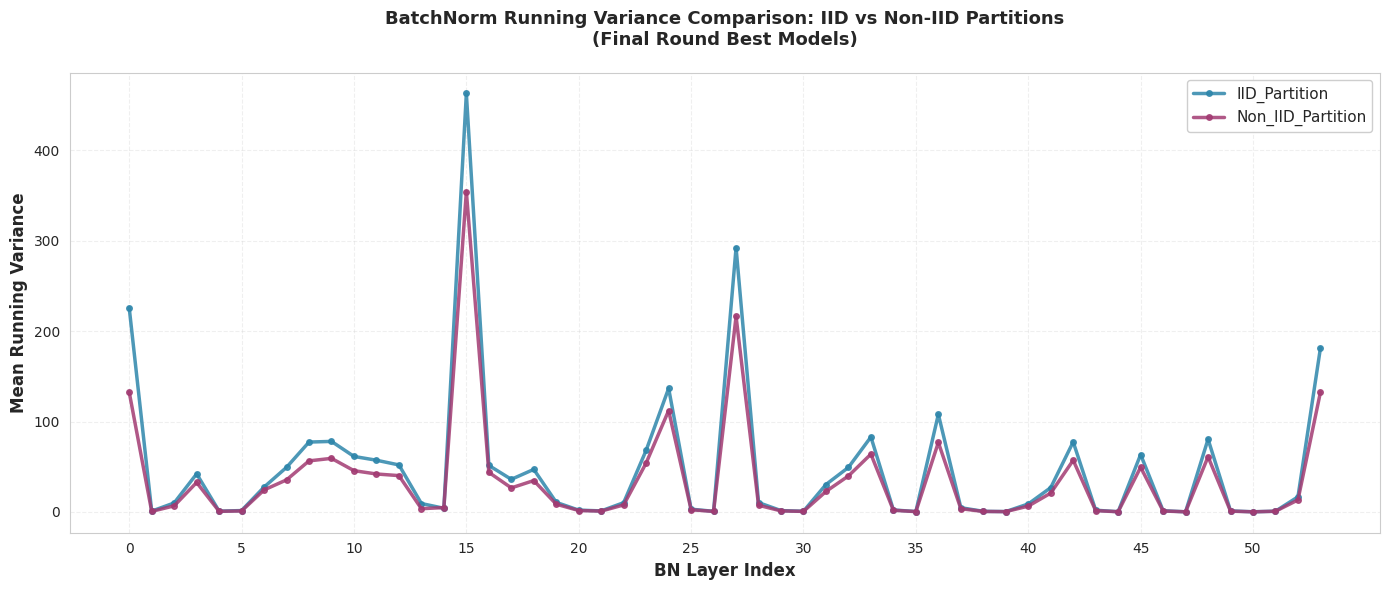


PER-LAYER VARIANCE COMPARISON TABLE

 Layer_Index                Layer_Name  IID_Running_Var  NonIID_Running_Var  Difference  Pct_Difference
           0                bga.conv.1       225.796326          132.459671   93.336655       70.464203
           1               bga.left1.1         0.803655            0.527482    0.276173       52.356827
           2               bga.left2.1         9.862014            6.641161    3.220852       48.498329
           3              bga.right1.1        42.053341           32.533554    9.519787       29.261440
           4              bga.right2.1         0.742686            0.607525    0.135161       22.247728
           5            detail.S1.0.bn         1.436378            1.002831    0.433548       43.232391
           6            detail.S1.1.bn        27.398283           24.237549    3.160734       13.040651
           7            detail.S2.0.bn        49.296799           35.413975   13.882824       39.201542
           8            de

In [ ]:
# ============================================================================
# Step 3: Create Per-Layer Variance Comparison Plot
# ============================================================================

if len(per_layer_variances) == 2:
    print("\n" + "="*70)
    print("GENERATING COMPARISON VISUALIZATION")
    print("="*70 + "\n")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = {
        'IID_Partition': '#2E86AB',      # Blue
        'Non_IID_Partition': '#A23B72'   # Red/Pink
    }
    
    # Plot per-layer running variance for each partition
    for partition_name in target_partitions:
        if partition_name in per_layer_variances:
            data = per_layer_variances[partition_name]
            layer_indices = np.arange(len(data['layer_names']))
            
            ax.plot(layer_indices, data['layer_variances'], 
                   marker='o', markersize=4, linewidth=2.5, 
                   label=partition_name, 
                   color=colors[partition_name],
                   alpha=0.85)
    
    # Formatting
    ax.set_xlabel('BN Layer Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Running Variance', fontsize=12, fontweight='bold')
    ax.set_title('BatchNorm Running Variance Comparison: IID vs Non-IID Partitions\n(Final Round Best Models)', 
                fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='best', framealpha=0.95)
    
    # Set x-axis to show all layers or subset of labels for readability
    n_layers = len(per_layer_variances[target_partitions[0]]['layer_names'])
    step = max(1, n_layers // 10)  # Show ~10 labels
    ax.set_xticks(range(0, n_layers, step))
    
    plt.tight_layout()
    
    # Save figure
    output_dir = Path('batchnorm_analysis_results')
    output_dir.mkdir(exist_ok=True)
    plot_path = output_dir / 'per_layer_variance_comparison_iid_non_iid.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Comparison plot saved: {plot_path}")
    
    plt.show()
    
    # ============================================================================
    # Step 4: Create Per-Layer Comparison Table
    # ============================================================================
    
    print("\n" + "="*70)
    print("PER-LAYER VARIANCE COMPARISON TABLE")
    print("="*70 + "\n")
    
    # Create comparison dataframe
    comparison_data = []
    
    iid_data = per_layer_variances['IID_Partition']
    non_iid_data = per_layer_variances['Non_IID_Partition']
    
    for layer_idx in range(len(iid_data['layer_names'])):
        layer_name = iid_data['layer_names'][layer_idx]
        iid_var = iid_data['layer_variances'][layer_idx]
        non_iid_var = non_iid_data['layer_variances'][layer_idx]
        
        difference = iid_var - non_iid_var
        pct_difference = (difference / non_iid_var * 100) if non_iid_var != 0 else 0
        
        comparison_data.append({
            'Layer_Index': layer_idx,
            'Layer_Name': layer_name,
            'IID_Running_Var': iid_var,
            'NonIID_Running_Var': non_iid_var,
            'Difference': difference,
            'Pct_Difference': pct_difference
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Display table
    print(comparison_df.to_string(index=False))
    
    # ============================================================================
    # Step 5: Summary Statistics
    # ============================================================================
    
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70 + "\n")
    
    iid_vars = comparison_df['IID_Running_Var'].values
    non_iid_vars = comparison_df['NonIID_Running_Var'].values
    
    print(f"IID_Partition Stats:")
    print(f"  Mean: {np.mean(iid_vars):.6f}")
    print(f"  Std:  {np.std(iid_vars):.6f}")
    print(f"  Min:  {np.min(iid_vars):.6f}")
    print(f"  Max:  {np.max(iid_vars):.6f}")
    
    print(f"\nNon_IID_Partition Stats:")
    print(f"  Mean: {np.mean(non_iid_vars):.6f}")
    print(f"  Std:  {np.std(non_iid_vars):.6f}")
    print(f"  Min:  {np.min(non_iid_vars):.6f}")
    print(f"  Max:  {np.max(non_iid_vars):.6f}")
    
    # Calculate difference statistics
    print(f"\nDifference (IID - NonIID):")
    print(f"  Mean: {np.mean(comparison_df['Difference']):.6f}")
    print(f"  Std:  {np.std(comparison_df['Difference']):.6f}")
    print(f"  Median: {np.median(comparison_df['Difference']):.6f}")
    
    # Test hypothesis: Do IID variances differ from Non-IID?
    from scipy.stats import ttest_rel, wilcoxon
    
    t_stat, t_pval = ttest_rel(iid_vars, non_iid_vars)
    print(f"\nPaired t-test (IID vs Non-IID):")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {t_pval:.6f}")
    print(f"  Result: {'Significant difference' if t_pval < 0.05 else 'No significant difference'} (α=0.05)")
    
    # Wilcoxon signed-rank test
    w_stat, w_pval = wilcoxon(iid_vars - non_iid_vars)
    print(f"\nWilcoxon Signed-Rank Test:")
    print(f"  W-statistic: {w_stat:.4f}")
    print(f"  p-value: {w_pval:.6f}")
    
    # ============================================================================
    # Step 6: Export Comparison to CSV
    # ============================================================================
    
    csv_path = output_dir / 'per_layer_variance_comparison_iid_non_iid.csv'
    comparison_df.to_csv(csv_path, index=False)
    print(f"\n✓ Comparison table exported: {csv_path}")
    
    print(f"\n{'='*70}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*70}")
else:
    print(f"\n✗ Cannot create comparison: Not all required partitions available")
    print(f"  Expected: IID_Partition, Non_IID_Partition")
    print(f"  Found: {list(per_layer_variances.keys())}")